# Feature Engineering
### **Mohon membaca setiap instruksi dan tag komentar dengan saksama sebelum melanjutkan pengerjaan.**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

# Scalling untuk MinMax Scaller
from sklearn.preprocessing import MinMaxScaler
# Set the maximum number of columns and rows to display to a large number
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# B. Outlier Handling

### Outlier Handling : InterQuartile Handling

In [2]:
# untuk plot Q-Q
import scipy.stats as stats

In [3]:
df_california = pd.read_csv('california_dataset.csv')

In [4]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df_california,
    test_size=0.2,
    random_state=42
)



### Assignment 1.a :
1. lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms','AveBedrms', 'AveOccup'] di california_dataset.csv
2. Daftar nama kolom yang Anda cek, kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

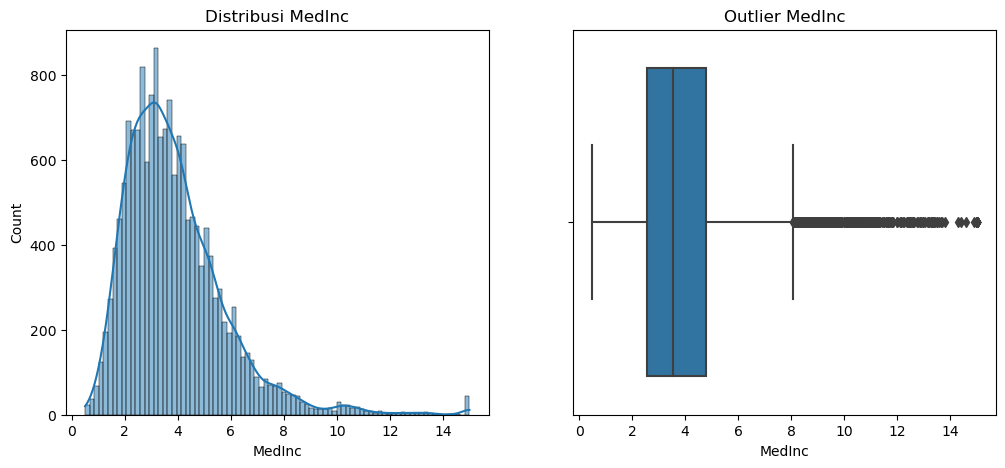

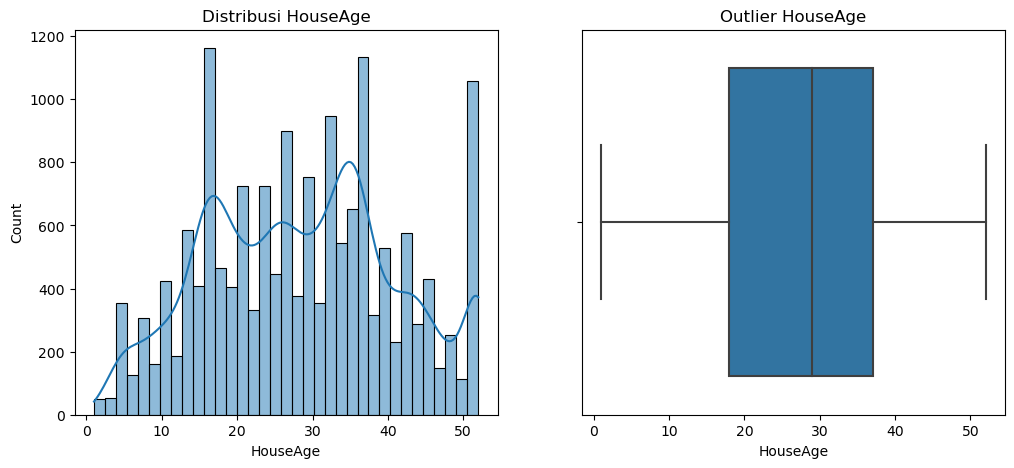

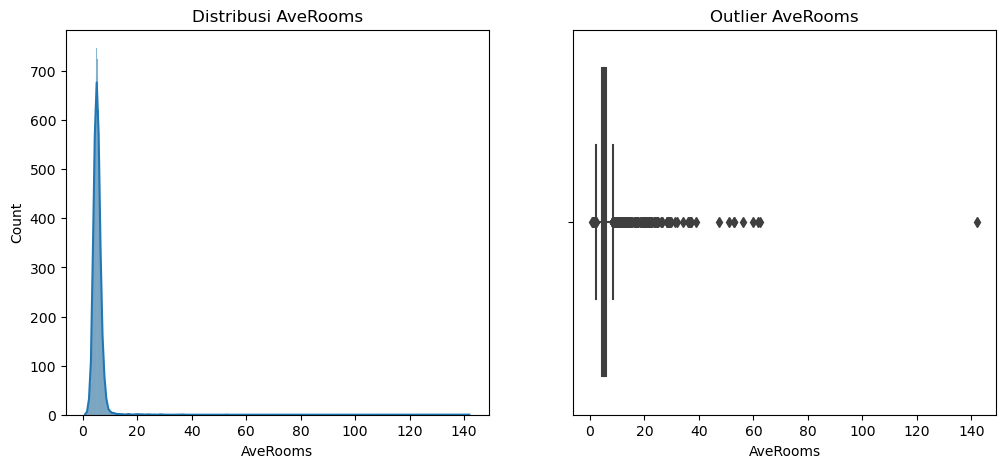

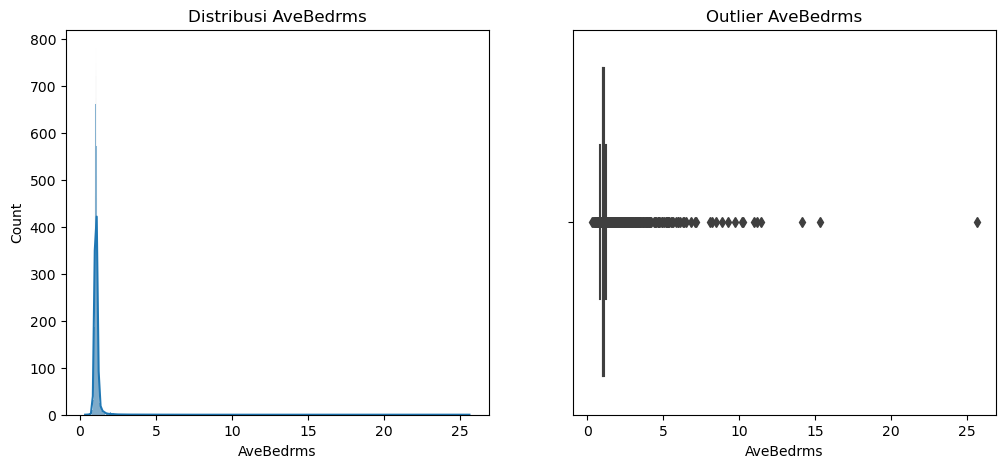

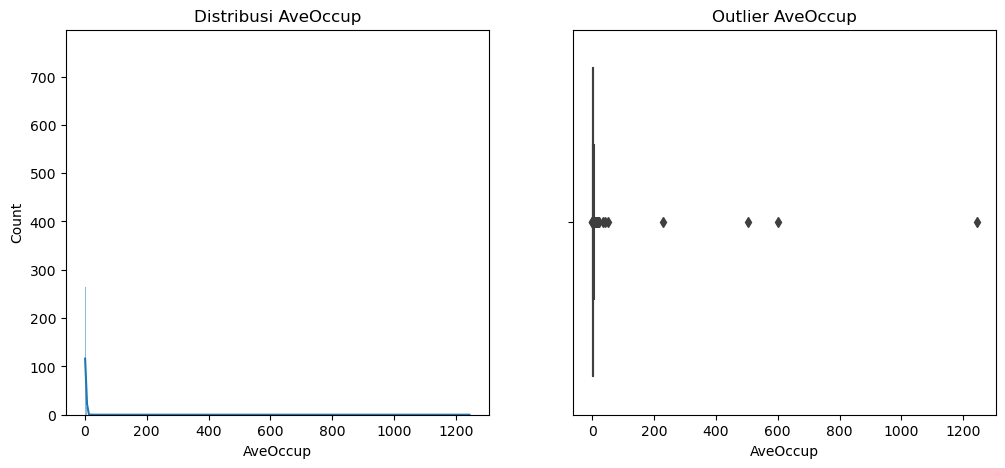

In [5]:
column = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

for kolom in column:
    
    plt.figure(figsize=(12,5))
    
    plt.subplot(1,2,1)
    sns.histplot(train_df[kolom], kde=True)
    plt.title(f'Distribusi {kolom}')
    
    plt.subplot(1,2,2)
    sns.boxplot(x=train_df[kolom])
    plt.title(f'Outlier {kolom}')
    
    plt.show()





### Assignment 1.b
1. Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
2. Dan cek distribusinya kembali

In [6]:
column = 'AveOccup'

Q1 = train_df[column].quantile(0.25)
Q3 = train_df[column].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

train_df_iqr = train_df[
    (train_df[kolom] >= lower_bound) &
    (train_df[kolom] <= upper_bound)
]


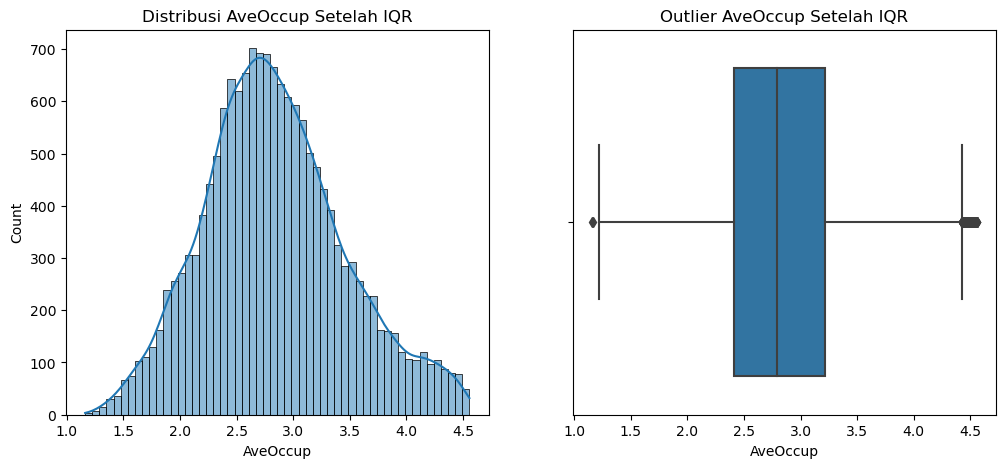

In [7]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(train_df_iqr[kolom], kde=True)
plt.title(f'Distribusi {kolom} Setelah IQR')

plt.subplot(1,2,2)
sns.boxplot(x=train_df_iqr[kolom])
plt.title(f'Outlier {kolom} Setelah IQR')

plt.show()


# C. Missing Value Handling
Missing Value Merupakan nilai yang hilang di suatu kolom, namun tidak hanya sebatas itu. Untuk nilai yang tidak sesuai tapi muncul didalam suatu kolom tertentu juga bisa dianggap sebagai missing value. Misal tipenya kategorikal tapi isinya ada yang berupa angka dan juga sebaliknya.

In [8]:
df_company = pd.read_csv('company.csv')

### Aturan missing value handling :
1. jika tipe datanya itu **numerik** -> handling menggunakan **median** (robust / tahan terhadap outlier)
2. jika tipe datanya itu **kategorik / object / string** -> handling menggunakan **mode / modus**

In [9]:
from sklearn.model_selection import train_test_split

train_company, test_company = train_test_split(
    df_company,
    test_size=0.2,
    random_state=42
)

## Assignment 2. Missing Value Handling :
1. Cek persentase missing value pada kolom Headquarters di company.csv, Cek jenis missing valuenya ?
2. apakah di drop atau tidak (gunakan syarat drop kolom jika > 20%)
3. jika tidak maka handling, dan dengan cara apa handling nilainya, median atau modus ?

In [10]:
missing_value = train_company['Headquarters'].isnull().sum()
total_data = len(train_company)
missing_percentage = (missing_value / total_data) * 100

print("Jumlah Missing Value :", missing_value)
print("Persentase Missing Value :", missing_percentage, "%")


Jumlah Missing Value : 0
Persentase Missing Value : 0.0 %


In [11]:
print("Tipe Data :", train_company['Headquarters'].dtype)


if missing_percentage > 20:
    train_company = train_company.drop(columns=['Headquarters'])
    print("Kolom Headquarters di-drop karena missing value > 20%")
else:
    
    mode_value = train_company['Headquarters'].mode()[0]
    train_company['Headquarters'] = train_company['Headquarters'].fillna(mode_value)
    print("Missing value di-handle menggunakan modus")

Tipe Data : object
Missing value di-handle menggunakan modus


# D. Encoding
Definisi : Mengubah tipe kategorikal menjadi numerikal dengan pendekatan aturan encoding untuk persiapan sebelum dilakukannya machine learning modelling. Teknik Encoding yang umum dipakai :
1. One Hot Encoding (OHE) : Lakukan pada kolom gender
2. Label Encoding / Ordinal Encoding : Lakukan pada kolom Yes dan No, Jika Yes menjadi 1 , Jika No menjadi 0. Sebagai Contohnya di kolom  Partner, Dependents.
3. Mean Encoding : Contract

In [20]:
df_churn = pd.read_excel('TelcoCustomerChurn.xlsx')

In [22]:
from sklearn.model_selection import train_test_split

train_churn, test_churn = train_test_split(
    df_churn,
    test_size=0.2,
    random_state=42
)


## Assignment 3.a Label Encoder :
1. Pilih kolom-kolom StreamingMovies, StreamingTV, TechSupport, DeviceProtection, OnlineBackup, OnlineSecurity, MultipleLines
2. Ganti nilai yang tidak sesuai : No internet service menjadi No lalu validasi dengan value_counts
3. Kemudian lakukan label Encoder
4. Notes : gunakan Telco-Customer-Churn.csv

In [23]:
#Tulis jawaban
from sklearn.preprocessing import LabelEncoder


In [24]:
kolom_label = ['StreamingMovies','StreamingTV','TechSupport','DeviceProtection',
               'OnlineBackup','OnlineSecurity','MultipleLines']

In [25]:
for kolom in kolom_label:
    train_churn[kolom] = train_churn[kolom].replace('No internet service','No')

for kolom in kolom_label:
    print(kolom)
    print(train_churn[kolom].value_counts())
    print()

StreamingMovies
StreamingMovies
No     3437
Yes    2197
Name: count, dtype: int64

StreamingTV
StreamingTV
No     3453
Yes    2181
Name: count, dtype: int64

TechSupport
TechSupport
No     4005
Yes    1629
Name: count, dtype: int64

DeviceProtection
DeviceProtection
No     3703
Yes    1931
Name: count, dtype: int64

OnlineBackup
OnlineBackup
No     3662
Yes    1972
Name: count, dtype: int64

OnlineSecurity
OnlineSecurity
No     4024
Yes    1610
Name: count, dtype: int64

MultipleLines
MultipleLines
No                  2685
Yes                 2397
No phone service     552
Name: count, dtype: int64



In [26]:
le = LabelEncoder()

for kolom in kolom_label:
    train_churn[kolom] = le.fit_transform(train_churn[kolom])

## Selesai :)